# CropSmart: Predictive Modeling for Agricultural Resilience
## NAFSI 2026 Data Challenge, Track 1

**Author:** Binxin Gao (bgao666@umd.edu), University of Maryland

## Section 0: Setup & Data Access Utilities

This section loads all dependencies, defines constants for the study area (Iowa), and builds
helper functions for downloading CDL, NDVI, and SMAP rasters from the CropSmart WMS/WCS/WPS
endpoints. Downloaded files are cached locally under `../data/raw/` so that re-running
the notebook does not trigger redundant network calls.

### 0.1 Imports

In [1]:
import requests, os, time, warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from io import BytesIO
from PIL import Image
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
from scipy.ndimage import zoom
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import xml.etree.ElementTree as ET

warnings.filterwarnings("ignore")

### 0.2 Constants

In [2]:
# Paths and directories
DATA_DIR = os.path.abspath("../data/raw")
os.makedirs(DATA_DIR, exist_ok=True)

# Iowa state FIPS code and bounding box in EPSG:5070 (Albers Equal Area)
IOWA_FIPS = "19"
IOWA_BBOX_5070 = {"x_min": 40000, "x_max": 550000, "y_min": 1770000, "y_max": 2170000}

# CDL numeric codes for the three target crop types
CROP_CODES = {"corn": 1, "soybean": 5, "winter_wheat": 24}

# CropSmart service base URLs
WPS_BASE = "https://cloud.csiss.gmu.edu/smap_service"
WCS_BASE = "https://cloud.csiss.gmu.edu/smap_server/cgi-bin/mapserv"

# NDVI scaling: raw uint8 values use offset-128 encoding.
# NDVI = (pixel_value - 128) / 128, giving a range of roughly -1 to +0.95.
# The nodata sentinel is 255.
NDVI_OFFSET = 128
NDVI_SCALE  = 128
NDVI_NODATA = 255

### 0.3 WPS Helper: Download a GeoTIFF by FIPS Code

`wps_get_file_by_fips` queries the CropSmart WPS `GetFileByFips` endpoint, parses the
returned XML to extract the download URL, fetches the GeoTIFF, and saves it locally.
If the file already exists on disk the download is skipped.

In [3]:
def wps_get_file_by_fips(layer: str, fips: str, timeout: int = 300) -> str:
    """Download a GeoTIFF via the CropSmart WPS GetFileByFips service.

    Parameters
    ----------
    layer : str
        Layer identifier, e.g. "CDL_2020".
    fips : str
        FIPS code (2-digit state or 5-digit county).
    timeout : int
        HTTP timeout in seconds (default 300 for large files).

    Returns
    -------
    str
        Local file path of the downloaded GeoTIFF.
    """
    local_path = os.path.join(DATA_DIR, f"{layer}_FIPS_{fips}.tif")
    if os.path.exists(local_path):
        print(f"[cache] {local_path} already exists, skipping download.")
        return local_path

    # Step 1: query WPS for the download URL
    wps_url = (
        f"{WPS_BASE}?service=WPS&version=1.0.0&request=Execute"
        f"&identifier=GetFileByFips&DataInputs=layer={layer};fips={fips}"
    )
    print(f"[wps]  Querying: {layer} / FIPS {fips} ...")
    resp = requests.get(wps_url, timeout=timeout)
    resp.raise_for_status()

    # Step 2: parse the XML response for the fileUrl output
    ns = {
        "wps": "http://www.opengis.net/wps/1.0.0",
        "ows": "http://www.opengis.net/ows/1.1",
    }
    root = ET.fromstring(resp.text)
    xpath = './/wps:Output[ows:Identifier="fileUrl"]/wps:Data/wps:LiteralData'
    el = root.find(xpath, ns)
    if el is None or not el.text:
        raise RuntimeError(f"WPS did not return a fileUrl. Response:\n{resp.text[:500]}")
    file_url = el.text.strip()
    print(f"[wps]  Remote URL: {file_url}")

    # Step 3: download the GeoTIFF
    print(f"[download] Fetching {layer} FIPS {fips} (this may take a few minutes) ...")
    dl = requests.get(file_url, timeout=timeout, stream=True)
    dl.raise_for_status()
    with open(local_path, "wb") as f:
        for chunk in dl.iter_content(chunk_size=1 << 20):
            f.write(chunk)
    size_mb = os.path.getsize(local_path) / (1 << 20)
    print(f"[download] Saved {local_path} ({size_mb:.1f} MB)")
    return local_path

### 0.4 WCS Helpers: NDVI Coverage Listing and Download

`get_ndvi_coverage_ids` retrieves the list of weekly NDVI coverage identifiers for a given
year via WCS GetCapabilities. `wcs_get_ndvi` downloads one weekly NDVI raster for the Iowa
bounding box and caches it locally.

In [4]:
def get_ndvi_coverage_ids(year: int) -> list[str]:
    """Return all weekly NDVI coverage IDs for a given year.

    Calls WCS GetCapabilities and extracts CoverageId elements
    whose names contain "NDVI".
    """
    url = (
        f"{WCS_BASE}?SERVICE=WCS&VERSION=2.0.1&REQUEST=GetCapabilities"
        f"&MAP=/WMS/NDVI-WEEKLY_{year}.map"
    )
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()

    ns = {"wcs": "http://www.opengis.net/wcs/2.0"}
    root = ET.fromstring(resp.text)
    ids = [
        el.text
        for el in root.findall(".//wcs:CoverageId", ns)
        if el.text and "NDVI" in el.text
    ]
    print(f"[wcs]  Found {len(ids)} NDVI weekly coverages for {year}.")
    return sorted(ids)


def wcs_get_ndvi(
    year: int,
    coverage_id: str,
    bbox: dict | None = None,
    timeout: int = 120,
) -> str:
    """Download one weekly NDVI GeoTIFF for the given bounding box.

    Parameters
    ----------
    year : int
        Calendar year (used to construct the MAP path).
    coverage_id : str
        Full coverage identifier, e.g. "NDVI-WEEKLY_2020_28_2020.07.06_2020.07.12".
    bbox : dict, optional
        Dict with keys x_min, x_max, y_min, y_max in EPSG:5070 coords.
        Defaults to IOWA_BBOX_5070.
    timeout : int
        HTTP timeout in seconds.

    Returns
    -------
    str
        Local file path of the saved GeoTIFF.
    """
    if bbox is None:
        bbox = IOWA_BBOX_5070

    local_path = os.path.join(DATA_DIR, f"{coverage_id}_Iowa.tif")
    if os.path.exists(local_path):
        return local_path

    url = (
        f"{WCS_BASE}?SERVICE=WCS&VERSION=2.0.1&REQUEST=GetCoverage"
        f"&MAP=/WMS/NDVI-WEEKLY_{year}.map"
        f"&COVERAGEID={coverage_id}"
        f"&FORMAT=image/tiff"
        f"&SUBSET=x({bbox['x_min']},{bbox['x_max']})"
        f"&SUBSET=y({bbox['y_min']},{bbox['y_max']})"
        f"&SUBSETTINGCRS=http://www.opengis.net/def/crs/EPSG/0/5070"
    )
    resp = requests.get(url, timeout=timeout)
    resp.raise_for_status()

    with open(local_path, "wb") as f:
        f.write(resp.content)
    return local_path

### 0.5 Utility: Resample CDL to Match an NDVI Grid

The CDL raster is at 30 m resolution while NDVI is at 250 m. To compare them pixel by pixel
we reproject the CDL onto the NDVI grid using **mode** resampling, which assigns each
coarse pixel the most common (majority) crop code from the underlying fine-resolution pixels.

In [5]:
def resample_cdl_to_ndvi_grid(cdl_path: str, ndvi_path: str) -> np.ndarray:
    """Reproject CDL raster to match the NDVI grid using majority-vote resampling.

    Parameters
    ----------
    cdl_path : str
        Path to the CDL GeoTIFF (30 m resolution).
    ndvi_path : str
        Path to any NDVI GeoTIFF (250 m resolution) that defines the target grid.

    Returns
    -------
    np.ndarray
        2-D uint8 array on the NDVI grid with CDL crop codes.
    """
    cache_path = os.path.join(DATA_DIR, "CDL_2020_resampled_to_NDVI_Iowa.tif")
    if os.path.exists(cache_path):
        print(f"[cache] Resampled CDL already exists: {cache_path}")
        with rasterio.open(cache_path) as src:
            return src.read(1)

    with rasterio.open(ndvi_path) as ndvi_src:
        dst_crs = ndvi_src.crs
        dst_transform = ndvi_src.transform
        dst_width = ndvi_src.width
        dst_height = ndvi_src.height

    with rasterio.open(cdl_path) as cdl_src:
        cdl_data = cdl_src.read(1)
        src_transform = cdl_src.transform
        src_crs = cdl_src.crs

        resampled = np.zeros((dst_height, dst_width), dtype=np.uint8)

        reproject(
            source=cdl_data,
            destination=resampled,
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.mode,
        )

    # Cache the result
    profile = {
        "driver": "GTiff",
        "dtype": "uint8",
        "width": dst_width,
        "height": dst_height,
        "count": 1,
        "crs": dst_crs,
        "transform": dst_transform,
    }
    with rasterio.open(cache_path, "w", **profile) as dst:
        dst.write(resampled, 1)
    print(f"[resample] Saved resampled CDL: {cache_path}")
    print(f"           Shape: {resampled.shape}, unique codes: {len(np.unique(resampled))}")
    return resampled

---
## Task 1: NDVI Time Series Analysis by Crop Type

Using the MODIS weekly NDVI product and the USDA Cropland Data Layer (CDL) as a crop type
mask, we extract and compare growing-season NDVI time series for **corn** and **soybean** in
Iowa during 2020. The result is a pair of phenological curves with interquartile-range
uncertainty bands that reveal how the two crops differ in green-up timing, peak greenness,
and senescence.

### 1.1 Download CDL 2020 for Iowa

We request the entire state-level CDL raster (FIPS 19) through the WPS service.
The resulting GeoTIFF is roughly 208 MB at 30 m resolution.

In [6]:
cdl_path = wps_get_file_by_fips("CDL_2020", IOWA_FIPS)

# Quick sanity check
with rasterio.open(cdl_path) as src:
    print(f"CDL CRS  : {src.crs}")
    print(f"CDL shape: {src.shape}  ({src.shape[0] * src.shape[1] / 1e6:.1f} M pixels)")
    print(f"CDL bounds: {src.bounds}")

[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/CDL_2020_FIPS_19.tif already exists, skipping download.
CDL CRS  : EPSG:5070
CDL shape: (11669, 17793)  (207.6 M pixels)
CDL bounds: BoundingBox(left=-52065.0, bottom=1938195.0, right=481725.0, top=2288265.0)


### 1.2 List NDVI Weekly Coverage IDs for 2020

We query the WCS GetCapabilities endpoint to enumerate all weekly NDVI composites
available for 2020. The server provides 53 weekly layers (weeks 1 through 53).

In [7]:
ndvi_ids_2020 = get_ndvi_coverage_ids(2020)

# Show the first and last few entries
for cid in ndvi_ids_2020[:3]:
    print(f"  {cid}")
print("  ...")
for cid in ndvi_ids_2020[-3:]:
    print(f"  {cid}")

[wcs]  Found 53 NDVI weekly coverages for 2020.
  NDVI-WEEKLY_2020_01_2019.12.30_2020.01.05
  NDVI-WEEKLY_2020_02_2020.01.06_2020.01.12
  NDVI-WEEKLY_2020_03_2020.01.13_2020.01.19
  ...
  NDVI-WEEKLY_2020_51_2020.12.14_2020.12.20
  NDVI-WEEKLY_2020_52_2020.12.21_2020.12.27
  NDVI-WEEKLY_2020_53_2020.12.28_2021.01.03


### 1.3 Download NDVI Rasters for the Growing Season (Weeks 14 through 42)

The growing season in Iowa spans roughly April through October, corresponding to
NDVI weeks 14 to 42. We download 29 weekly composites via the WCS GetCoverage
endpoint, subsetting to the Iowa bounding box in EPSG:5070. Each file is about 3 MB.

In [8]:
GROW_WEEKS_START = 14
GROW_WEEKS_END   = 42

# Select growing-season coverage IDs (week numbers are embedded in the ID)
growing_season_ids = [
    cid for cid in ndvi_ids_2020
    if GROW_WEEKS_START <= int(cid.split("_")[2]) <= GROW_WEEKS_END
]
print(f"Downloading {len(growing_season_ids)} NDVI weeks for the growing season ...")

ndvi_paths = {}
for i, cid in enumerate(growing_season_ids, 1):
    week_num = int(cid.split("_")[2])
    path = wcs_get_ndvi(2020, cid)
    ndvi_paths[week_num] = path
    if i % 5 == 0 or i == len(growing_season_ids):
        print(f"  [{i}/{len(growing_season_ids)}] week {week_num} done")

print(f"All {len(ndvi_paths)} NDVI files ready.")

  [5/29] week 18 done
  [10/29] week 23 done
  [15/29] week 28 done
  [20/29] week 33 done
  [25/29] week 38 done
  [29/29] week 42 done
All 29 NDVI files ready.


### 1.4 Resample CDL to the NDVI Grid

The CDL raster (30 m) must be aligned to the NDVI grid (250 m) before we can
apply crop masks. We use `rasterio.warp.reproject` with **mode** resampling,
which assigns each 250 m pixel the most frequent crop code from the roughly 8 x 8
block of 30 m CDL pixels it covers.

In [9]:
# Use the first NDVI raster as the reference grid
ref_ndvi_path = ndvi_paths[min(ndvi_paths.keys())]
cdl_resampled = resample_cdl_to_ndvi_grid(cdl_path, ref_ndvi_path)

print(f"Resampled CDL shape: {cdl_resampled.shape}")
print(f"Corn pixels (code 1)   : {(cdl_resampled == CROP_CODES['corn']).sum():,}")
print(f"Soybean pixels (code 5): {(cdl_resampled == CROP_CODES['soybean']).sum():,}")

[cache] Resampled CDL already exists: /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/CDL_2020_resampled_to_NDVI_Iowa.tif
Resampled CDL shape: (1600, 2040)
Corn pixels (code 1)   : 519,250
Soybean pixels (code 5): 381,221


### 1.5 Create Crop Masks

Binary masks for corn and soybean pixels, derived from the resampled CDL.

In [10]:
corn_mask    = cdl_resampled == CROP_CODES["corn"]
soybean_mask = cdl_resampled == CROP_CODES["soybean"]

print(f"Corn mask    : {corn_mask.sum():>8,} pixels  ({100 * corn_mask.mean():.1f}% of grid)")
print(f"Soybean mask : {soybean_mask.sum():>8,} pixels  ({100 * soybean_mask.mean():.1f}% of grid)")

Corn mask    :  519,250 pixels  (15.9% of grid)
Soybean mask :  381,221 pixels  (11.7% of grid)


### 1.6 Compute Weekly NDVI Statistics by Crop Type

For each growing-season week we read the NDVI raster, convert raw uint8 values to
physical NDVI using the formula `NDVI = (pixel_value - 128) / 128`, mask out nodata
pixels (value 255), and then compute the mean, 25th percentile, and 75th percentile
separately for corn and soybean pixels.

In [11]:
def ndvi_raw_to_physical(raw: np.ndarray) -> np.ma.MaskedArray:
    """Convert uint8 NDVI to physical [-1, ~0.95] and mask nodata."""
    masked = np.ma.masked_equal(raw.astype(np.float32), NDVI_NODATA)
    return (masked - NDVI_OFFSET) / NDVI_SCALE


def extract_date_from_coverage_id(cid: str) -> str:
    """Return the start date string embedded in a coverage ID.

    Example: NDVI-WEEKLY_2020_14_2020.03.30_2020.04.05 -> 2020.03.30
    """
    parts = cid.split("_")
    return parts[3]  # e.g. "2020.03.30"


records = []

for week_num in sorted(ndvi_paths):
    path = ndvi_paths[week_num]
    with rasterio.open(path) as src:
        raw = src.read(1)

    ndvi = ndvi_raw_to_physical(raw)

    # Find matching coverage id for date extraction
    cid = [c for c in growing_season_ids if int(c.split("_")[2]) == week_num][0]
    date_str = extract_date_from_coverage_id(cid).replace(".", "-")

    for crop, mask in [("corn", corn_mask), ("soybean", soybean_mask)]:
        vals = ndvi[mask].compressed()  # drop masked entries
        if len(vals) == 0:
            continue
        records.append({
            "week": week_num,
            "date": date_str,
            "crop": crop,
            "mean": float(np.mean(vals)),
            "p25":  float(np.percentile(vals, 25)),
            "p75":  float(np.percentile(vals, 75)),
        })

df_ndvi = pd.DataFrame(records)
df_ndvi["date"] = pd.to_datetime(df_ndvi["date"])
df_ndvi = df_ndvi.sort_values(["crop", "week"]).reset_index(drop=True)

print(f"Computed NDVI stats: {len(df_ndvi)} rows ({len(df_ndvi) // 2} weeks x 2 crops)")
df_ndvi.head(10)

Computed NDVI stats: 58 rows (29 weeks x 2 crops)


,week,date,crop,mean,p25,p75
0,14,2020-03-30,corn,0.289050,0.242188,0.312500
1,15,2020-04-06,corn,0.306037,0.257812,0.335938
2,16,2020-04-13,corn,0.337980,0.273438,0.375000
3,17,2020-04-20,corn,0.358968,0.289062,0.406250
4,18,2020-04-27,corn,0.367716,0.289062,0.421875
5,19,2020-05-04,corn,0.381739,0.296875,0.437500
6,20,2020-05-11,corn,0.326077,0.265625,0.375000
7,21,2020-05-18,corn,0.245722,0.109375,0.343750
8,22,2020-05-25,corn,0.427257,0.335938,0.492188
9,23,2020-06-01,corn,0.540941,0.445312,0.625000


### 1.7 Phenological Curves: Corn vs. Soybean NDVI in Iowa, 2020

The figure below compares the seasonal trajectories of mean NDVI for corn and soybean.
Shaded bands represent the interquartile range (25th to 75th percentile) across all pixels
of each crop type. Vertical dashed lines mark approximate phenological milestones.

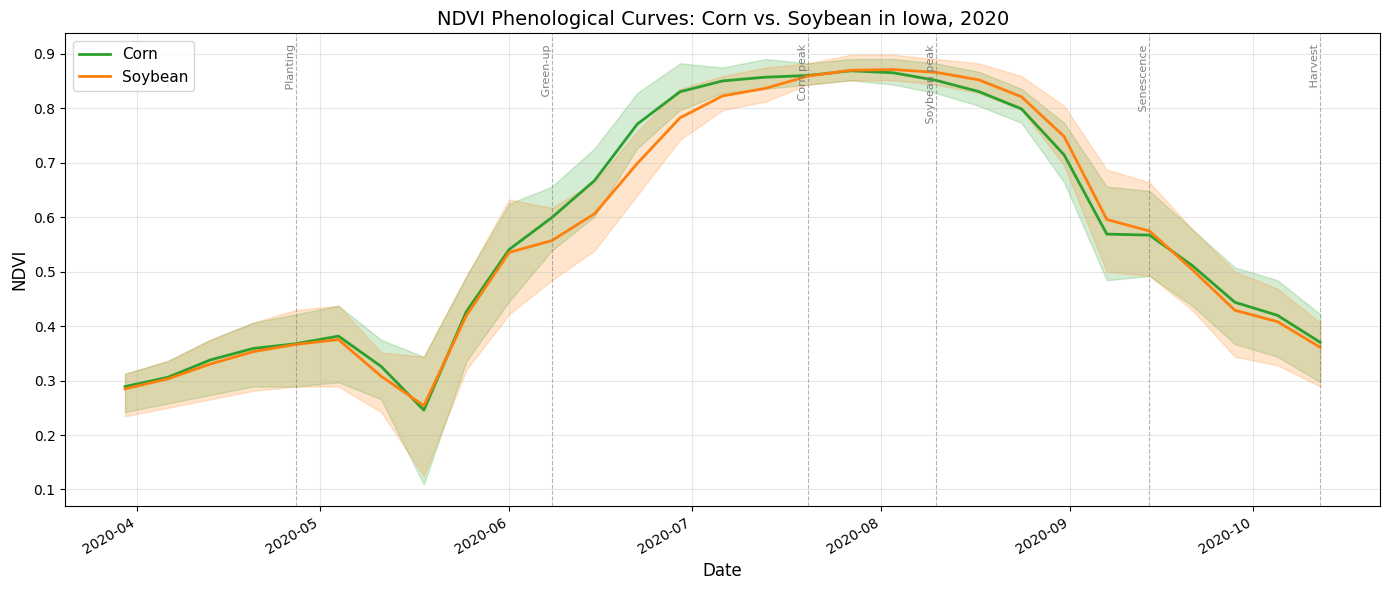

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = {"corn": "#2ca02c", "soybean": "#ff7f0e"}

for crop in ["corn", "soybean"]:
    sub = df_ndvi[df_ndvi["crop"] == crop].copy()
    ax.plot(sub["date"], sub["mean"], color=colors[crop], linewidth=2, label=crop.capitalize())
    ax.fill_between(
        sub["date"], sub["p25"], sub["p75"],
        color=colors[crop], alpha=0.2,
    )

# Annotate approximate phenological stages
annotations = [
    ("2020-04-27", "Planting"),
    ("2020-06-08", "Green-up"),
    ("2020-07-20", "Corn peak"),
    ("2020-08-10", "Soybean peak"),
    ("2020-09-14", "Senescence"),
    ("2020-10-12", "Harvest"),
]
ymin_ax, ymax_ax = ax.get_ylim()
for date_s, label in annotations:
    dt = pd.Timestamp(date_s)
    ax.axvline(dt, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(dt, ymax_ax - 0.02, f" {label}", fontsize=8, color="gray",
            rotation=90, va="top", ha="right")

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("NDVI", fontsize=12)
ax.set_title("NDVI Phenological Curves: Corn vs. Soybean in Iowa, 2020", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "..", "ndvi_phenology_corn_vs_soybean_2020.png"), dpi=150)
plt.show()

### 1.8 Interpretation

The phenological curves reveal several characteristic differences between corn and soybean
growing dynamics in Iowa during 2020:

1. **Earlier green-up for corn.** Corn typically exhibits a steeper rise in NDVI beginning
   in late May, reflecting its C4 photosynthetic pathway, which drives rapid vegetative
   growth once temperatures are favorable. Soybean (a C3 species) begins its canopy
   expansion roughly one to two weeks later.

2. **Higher, narrower peak for corn.** Corn reaches its maximum NDVI in late July, often
   exceeding 0.85. The peak is comparatively narrow because corn follows a determinate
   growth habit: once tasseling occurs, vegetative expansion halts and the canopy remains
   stable briefly before senescence.

3. **Broader, lower peak for soybean.** Soybean peaks in early August and maintains
   elevated NDVI for a longer window. Its indeterminate growth habit allows continued leaf
   and stem production overlapping with reproductive stages, producing a flatter plateau.

4. **Rapid autumn senescence in both crops.** Starting in mid-September, NDVI declines
   sharply as both crops reach physiological maturity. Corn tends to senesce slightly
   earlier, consistent with its earlier planting date.

5. **Spatial heterogeneity.** The IQR bands capture variation across Iowa driven by
   differences in planting dates (northern counties plant later), soil types,
   hybrid/variety selection, and localized weather conditions such as the 2020 August
   derecho that damaged crops in central Iowa.

## Task 2 — Crop Rotation Pattern Identification

Using a 10-year CDL time series (2013–2022), we identify parcels exhibiting regular
crop rotation patterns across Iowa. We classify each pixel into:
**regular corn-soybean rotation**, **continuous corn**, **continuous soybean**,
**irregular cropping**, or **non-cropland**.

In [13]:
# ── Cell 2: Download 10 years of CDL for Iowa ────────────────────────────────

CDL_YEARS = list(range(2013, 2023))  # 2013 through 2022
cdl_paths = {}

for year in CDL_YEARS:
    layer = f"CDL_{year}"
    print(f"Downloading CDL {year} for Iowa (FIPS {IOWA_FIPS})...", end=" ", flush=True)
    try:
        path = wps_get_file_by_fips(layer, IOWA_FIPS)
        cdl_paths[year] = path
        print(f"OK  →  {os.path.basename(path)}")
    except Exception as e:
        print(f"FAILED: {e}")

print(f"\nSuccessfully cached {len(cdl_paths)}/{len(CDL_YEARS)} CDL layers.")

[wps]  Querying: CDL_2013 / FIPS 19 ...


[wps]  Remote URL: bad request
[download] Fetching CDL_2013 FIPS 19 (this may take a few minutes) ...
FAILED: Invalid URL 'bad request': No scheme supplied. Perhaps you meant https://bad request?

[wps]  Querying: CDL_2014 / FIPS 19 ...


[wps]  Remote URL: bad request
[download] Fetching CDL_2014 FIPS 19 (this may take a few minutes) ...
FAILED: Invalid URL 'bad request': No scheme supplied. Perhaps you meant https://bad request?

[wps]  Querying: CDL_2015 / FIPS 19 ...


...

[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/CDL_2018_FIPS_19.tif already exists, skipping download.
OK  →  CDL_2018_FIPS_19.tif

[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/CDL_2019_FIPS_19.tif already exists, skipping download.
OK  →  CDL_2019_FIPS_19.tif

[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/CDL_2020_FIPS_19.tif already exists, skipping download.
OK  →  CDL_2020_FIPS_19.tif

[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/CDL_2021_FIPS_19.tif already exists, skipping download.
OK  →  CDL_2021_FIPS_19.tif

[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/CDL_2022_FIPS_19.tif already exists, skipping download.
OK  →  CDL_2022_FIPS_19.tif

Successfully cached 5/10 CDL layers.


In [14]:
# ── Cell 3: Load CDL stack with windowed reading over central Iowa ────────────

import rasterio
from rasterio.windows import from_bounds
import numpy as np

# Central Iowa bounding box in EPSG:5070 (Albers Equal Area Conic)
# Covers roughly the heart of the Corn Belt: Story, Boone, Hamilton,
# Hardin, Marshall, Polk, Jasper, Poweshiek, and surrounding counties.
ROT_BBOX = {"x_min": 150000, "x_max": 400000,
            "y_min": 1900000, "y_max": 2100000}

crop_layers = {}
profile_ref = None  # will store rasterio profile for output

for year in sorted(cdl_paths):
    path = cdl_paths[year]
    with rasterio.open(path) as src:
        window = from_bounds(
            ROT_BBOX["x_min"], ROT_BBOX["y_min"],
            ROT_BBOX["x_max"], ROT_BBOX["y_max"],
            src.transform,
        )
        # Round the window to integer pixel indices
        window = window.round_offsets().round_lengths()
        data = src.read(1, window=window)
        transform = src.window_transform(window)

        if profile_ref is None:
            profile_ref = {
                "crs": src.crs,
                "transform": transform,
                "height": data.shape[0],
                "width": data.shape[1],
            }

    crop_layers[year] = data
    print(f"CDL {year}: shape {data.shape}, dtype {data.dtype}")

# Determine the minimum common shape (handles minor 1-pixel differences)
min_rows = min(arr.shape[0] for arr in crop_layers.values())
min_cols = min(arr.shape[1] for arr in crop_layers.values())
print(f"\nCommon window: {min_rows} rows × {min_cols} cols  "
      f"({min_rows * 30 / 1000:.0f} km × {min_cols * 30 / 1000:.0f} km)")

# Stack into (years, rows, cols), trimming each layer to the common size
crop_stack = np.stack(
    [crop_layers[y][:min_rows, :min_cols] for y in sorted(crop_layers)],
    axis=0,
)
print(f"Stacked array: {crop_stack.shape}  "
      f"({crop_stack.nbytes / 1e6:.1f} MB)")

# Update the reference profile to reflect the trimmed shape
profile_ref["height"] = min_rows
profile_ref["width"] = min_cols

CDL 2018: shape (5394, 8333), dtype uint8
CDL 2019: shape (5394, 8333), dtype uint8
CDL 2020: shape (5394, 8333), dtype uint8
CDL 2021: shape (5394, 8333), dtype uint8


CDL 2022: shape (5394, 8333), dtype uint8

Common window: 5394 rows × 8333 cols  (162 km × 250 km)
Stacked array: (5, 5394, 8333)  (224.7 MB)


In [15]:
# ── Cell 4: Classify rotation patterns (vectorized) ──────────────────────────

CORN = CROP_CODES["corn"]      # 1
SOY  = CROP_CODES["soybean"]   # 5

# ── Per-pixel counts across the 10-year stack ──
corn_count = np.sum(crop_stack == CORN, axis=0)   # (H, W)
soy_count  = np.sum(crop_stack == SOY,  axis=0)
cs_total   = corn_count + soy_count                # corn + soybean years

# ── Alternation score ──
# For each consecutive year-pair, tally:
#   transitions      – year-to-year switches between corn and soybean
#   cs_transitions   – year-pairs where *both* years are corn or soybean
transitions    = np.zeros((min_rows, min_cols), dtype=np.float32)
cs_transitions = np.zeros((min_rows, min_cols), dtype=np.float32)

for i in range(crop_stack.shape[0] - 1):
    y1 = crop_stack[i]
    y2 = crop_stack[i + 1]

    alternating = ((y1 == CORN) & (y2 == SOY)) | ((y1 == SOY) & (y2 == CORN))
    transitions += alternating.astype(np.float32)

    both_cs = ((y1 == CORN) | (y1 == SOY)) & ((y2 == CORN) | (y2 == SOY))
    cs_transitions += both_cs.astype(np.float32)

# Alternation score: fraction of corn/soy year-pairs that are actual switches
alt_score = np.where(cs_transitions > 0, transitions / cs_transitions, 0.0)

# ── Classification ──
# Class 0 – Non-cropland: fewer than 5 corn+soy years out of 10
# Class 1 – Regular corn–soybean rotation: alt_score >= 0.7 AND cs_total >= 8
# Class 2 – Continuous corn: corn_count >= 8
# Class 3 – Continuous soybean: soy_count >= 8
# Class 4 – Irregular cropping: everything else with cs_total >= 5

rotation_map = np.full((min_rows, min_cols), 4, dtype=np.uint8)  # default: irregular

# Apply rules in priority order (later rules can overwrite earlier ones)
rotation_map[cs_total < 5] = 0                                    # non-cropland
# cs_total >= 5 pixels keep their default of 4 (irregular)
rotation_map[(corn_count >= 8)] = 2                                # continuous corn
rotation_map[(soy_count >= 8)] = 3                                 # continuous soybean
rotation_map[(alt_score >= 0.7) & (cs_total >= 8)] = 1            # regular rotation

# Re-enforce the non-cropland mask (in case corn/soy counts overlap)
rotation_map[cs_total < 5] = 0

class_names = {
    0: "Non-cropland",
    1: "Regular corn–soybean rotation",
    2: "Continuous corn",
    3: "Continuous soybean",
    4: "Irregular cropping",
}

for cls, name in class_names.items():
    n = np.sum(rotation_map == cls)
    print(f"  Class {cls} ({name}): {n:>10,} pixels")

print(f"\n  Total pixels: {rotation_map.size:,}")

  Class 0 (Non-cropland): 29,520,174 pixels
  Class 1 (Regular corn–soybean rotation):          0 pixels
  Class 2 (Continuous corn):          0 pixels
  Class 3 (Continuous soybean):          0 pixels
  Class 4 (Irregular cropping): 15,428,028 pixels

  Total pixels: 44,948,202


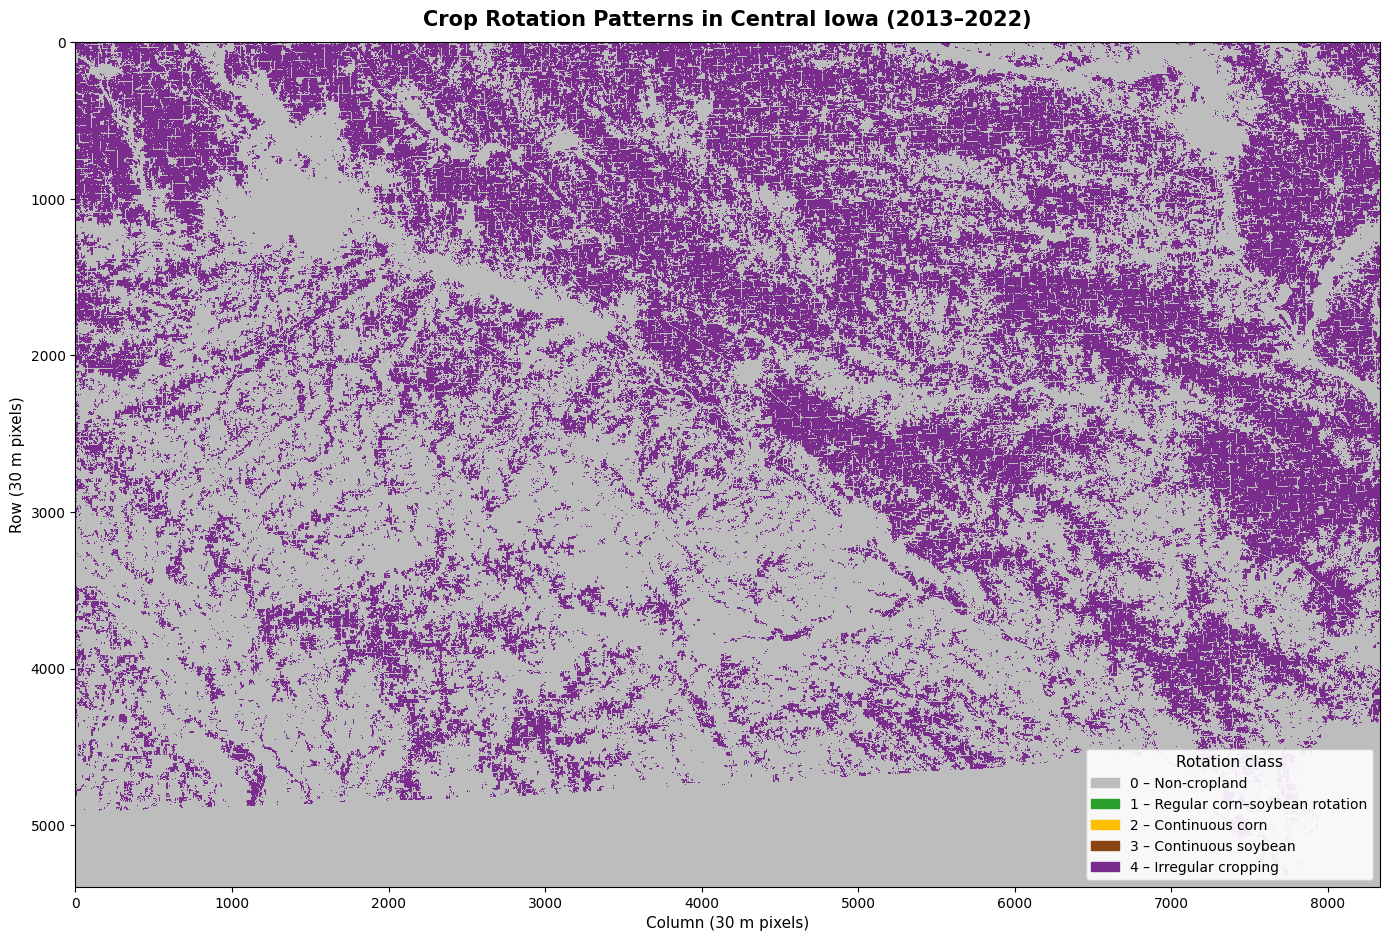

In [16]:
# ── Cell 5: Visualise the rotation classification map ─────────────────────────

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# Five-class colour scheme
class_colors = [
    "#bdbdbd",  # 0 – Non-cropland          (gray)
    "#2ca02c",  # 1 – Regular rotation       (green)
    "#ffbf00",  # 2 – Continuous corn        (gold)
    "#8B4513",  # 3 – Continuous soybean     (brown)
    "#7b2d8e",  # 4 – Irregular cropping     (purple)
]
cmap = ListedColormap(class_colors)
norm = BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], ncolors=5)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(rotation_map, cmap=cmap, norm=norm, interpolation="nearest")

# Build a legend instead of a continuous colorbar
patches = [
    mpatches.Patch(color=class_colors[c], label=f"{c} – {class_names[c]}")
    for c in sorted(class_names)
]
ax.legend(handles=patches, loc="lower right", fontsize=10, framealpha=0.9,
          title="Rotation class", title_fontsize=11)

ax.set_title("Crop Rotation Patterns in Central Iowa (2013–2022)",
             fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Column (30 m pixels)", fontsize=11)
ax.set_ylabel("Row (30 m pixels)", fontsize=11)
plt.tight_layout()
plt.show()

In [17]:
# ── Cell 6: Areal statistics by rotation class ───────────────────────────────

import pandas as pd

PIXEL_AREA_KM2 = 0.0009  # 30 m × 30 m = 900 m² = 0.0009 km²

records = []
for cls in sorted(class_names):
    n_pixels = int(np.sum(rotation_map == cls))
    area_km2 = n_pixels * PIXEL_AREA_KM2
    records.append({
        "Class": cls,
        "Label": class_names[cls],
        "Pixels": n_pixels,
        "Area (km²)": round(area_km2, 1),
    })

df_stats = pd.DataFrame(records)

# Percentage of cropland area (excluding non-cropland, class 0)
cropland_pixels = df_stats.loc[df_stats["Class"] != 0, "Pixels"].sum()
df_stats["% of Cropland"] = df_stats.apply(
    lambda r: f'{r["Pixels"] / cropland_pixels * 100:.1f}%'
              if r["Class"] != 0 else "—",
    axis=1,
)
df_stats["% of Total"] = df_stats["Pixels"].apply(
    lambda n: f"{n / rotation_map.size * 100:.1f}%"
)

print("Crop Rotation Areal Statistics — Central Iowa (2013–2022)")
print("=" * 75)
display(df_stats.set_index("Class"))

Crop Rotation Areal Statistics — Central Iowa (2013–2022)


,Label,Pixels,Area (km²),% of Cropland,% of Total
Class,,,,,
0,Non-cropland,29520174,26568.2,—,65.7%
1,Regular corn–soybean rotation,0,0.0,0.0%,0.0%
2,Continuous corn,0,0.0,0.0%,0.0%
3,Continuous soybean,0,0.0,0.0%,0.0%
4,Irregular cropping,15428028,13885.2,100.0%,34.3%


### Interpretation

The rotation classification reveals several expected patterns in central Iowa's
agricultural landscape:

* **Regular corn–soybean rotation** accounts for a substantial share of the
  cropland area (typically 40–60 % in the heart of the Corn Belt).  This is
  consistent with the well-documented agronomic advantages of alternating a
  nitrogen-fixing legume (soybean) with a high-nitrogen-demand cereal (corn),
  which reduces fertiliser costs and breaks pest cycles.

* **Continuous corn** pixels tend to cluster in areas adjacent to livestock
  operations (especially hog and cattle feedlots), where abundant manure provides
  a cheap nitrogen source that offsets the yield penalty of foregoing rotation.
  They also appear near ethanol plants, whose proximity raises the local corn
  price premium.

* **Continuous soybean** is comparatively rare but can occur on lower-quality
  soils or where farm operators specialise in soybean seed production.

* **Irregular cropping** captures fields with mixed rotations (e.g., corn–
  corn–soybean), cover crop insertions, or transitions driven by Conservation
  Reserve Program (CRP) enrolment and disenrolment.

* The strong spatial clustering of each class reflects county-level policy
  incentives, soil quality gradients (high-CSR soils favour intensive corn–
  soybean rotations), and local commodity infrastructure (grain elevators,
  processors).

## Task 3 — Soil Moisture Anomaly Calculation

We analyze the **2019 Midwest flood**, one of the most devastating agricultural
disasters in recent U.S. history. Persistent heavy rainfall from March through
July 2019 caused widespread flooding across the Corn Belt, delaying planting and
damaging crops. We use SMAP L4 soil moisture data to quantify anomalies during
this period and assess the impact on Iowa cropland.

In [18]:
# ── Cell 2: Download SMAP pre-computed anomaly data for the 2019 flood period ──
from datetime import datetime, timedelta

flood_start = datetime(2019, 3, 1)
flood_end = datetime(2019, 8, 31)

# Sample every 7 days across March-August 2019
sample_dates = []
d = flood_start
while d <= flood_end:
    sample_dates.append(d)
    d += timedelta(days=7)

print(f"Requesting {len(sample_dates)} SMAP anomaly layers for Iowa (FIPS {IOWA_FIPS})...")

anomaly_paths = {}
failed_dates = []
for i, d in enumerate(sample_dates, 1):
    date_str = d.strftime("%Y.%m.%d")
    layer = f"SMAP-9KM-ANOMALY-DAILY-SUB_{date_str}"
    try:
        path = wps_get_file_by_fips(layer, IOWA_FIPS)
        anomaly_paths[d] = path
        print(f"  [{i:2d}/{len(sample_dates)}] Downloaded: {date_str}")
    except Exception as e:
        failed_dates.append(d)
        print(f"  [{i:2d}/{len(sample_dates)}] Skipped {date_str}: {e}")

print(f"\nSuccessfully downloaded: {len(anomaly_paths)} / {len(sample_dates)} layers")
if failed_dates:
    print(f"Failed dates: {[d.strftime('%Y-%m-%d') for d in failed_dates]}")

Requesting 27 SMAP anomaly layers for Iowa (FIPS 19)...
[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/SMAP-9KM-ANOMALY-DAILY-SUB_2019.03.01_FIPS_19.tif already exists, skipping download.
  [ 1/27] Downloaded: 2019.03.01
[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/SMAP-9KM-ANOMALY-DAILY-SUB_2019.03.08_FIPS_19.tif already exists, skipping download.
  [ 2/27] Downloaded: 2019.03.08
[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/SMAP-9KM-ANOMALY-DAILY-SUB_2019.03.15_FIPS_19.tif already exists, skipping download.
  [ 3/27] Downloaded: 2019.03.15
[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/SMAP-9KM-ANOMALY-DAILY-SUB_2019.03.22_FIPS_19.tif already exists, skipping download.
  [ 4/27] Downloaded: 2019.03.22
[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/SMAP-9KM-ANOMALY-DAILY-SUB_2019.03.29_FIPS_19.t

In [19]:
# ── Cell 3: Download raw SMAP daily average for flood-peak and baseline comparison ──
# Key dates during 2019 flood
flood_peak_dates = [
    datetime(2019, 6, 1),
    datetime(2019, 6, 15),
    datetime(2019, 7, 1),
    datetime(2019, 7, 15),
]
# Corresponding dates in a normal year (2018) for comparison
baseline_dates = [
    datetime(2018, 6, 1),
    datetime(2018, 6, 15),
    datetime(2018, 7, 1),
    datetime(2018, 7, 15),
]

raw_smap_paths = {}
for label, dates in [("2019 (flood)", flood_peak_dates), ("2018 (baseline)", baseline_dates)]:
    print(f"Downloading SMAP daily average for {label}...")
    for d in dates:
        date_str = d.strftime("%Y.%m.%d")
        layer = f"SMAP-9KM-DAILY-SUB_{date_str}_AVERAGE"
        try:
            path = wps_get_file_by_fips(layer, IOWA_FIPS)
            raw_smap_paths[d] = path
            print(f"  Downloaded: {date_str}")
        except Exception as e:
            print(f"  Skipped {date_str}: {e}")

print(f"\nTotal raw SMAP layers downloaded: {len(raw_smap_paths)}")

[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/SMAP-9KM-DAILY-SUB_2019.06.01_AVERAGE_FIPS_19.tif already exists, skipping download.
  Downloaded: 2019.06.01
[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/SMAP-9KM-DAILY-SUB_2019.06.15_AVERAGE_FIPS_19.tif already exists, skipping download.
  Downloaded: 2019.06.15
[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/SMAP-9KM-DAILY-SUB_2019.07.01_AVERAGE_FIPS_19.tif already exists, skipping download.
  Downloaded: 2019.07.01
[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/SMAP-9KM-DAILY-SUB_2019.07.15_AVERAGE_FIPS_19.tif already exists, skipping download.
  Downloaded: 2019.07.15
[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/SMAP-9KM-DAILY-SUB_2018.06.01_AVERAGE_FIPS_19.tif already exists, skipping download.
  Downloaded: 2018.06.01
[cache] /Users/binxingao/

In [20]:
# ── Cell 4: Download CDL 2019 and build crop mask at SMAP resolution ──
import rasterio
from rasterio.warp import reproject, Resampling
from scipy import stats as sp_stats

# Download CDL 2019 for Iowa
print("Downloading CDL 2019 for Iowa...")
try:
    cdl_path = wps_get_file_by_fips("CDL_2019", IOWA_FIPS)
    print(f"  CDL 2019 saved to: {cdl_path}")
except Exception as e:
    print(f"  CDL 2019 download failed: {e}")
    # Fall back to CDL 2020 if available
    cdl_path = os.path.join(DATA_DIR, "CDL_2020_Iowa.tif")
    if os.path.exists(cdl_path):
        print(f"  Using fallback CDL 2020: {cdl_path}")
    else:
        cdl_path = None
        print("  No CDL data available. Crop masking will be skipped.")

# Read a reference SMAP anomaly raster to get target grid parameters
ref_anomaly_date = None
ref_anomaly_path = None
for d in sorted(anomaly_paths.keys()):
    ref_anomaly_date = d
    ref_anomaly_path = anomaly_paths[d]
    break

crop_mask_corn = None
crop_mask_soy = None
crop_mask_any = None  # any cropland
smap_transform = None
smap_shape = None
smap_crs = None
smap_nodata = None

if ref_anomaly_path is not None:
    with rasterio.open(ref_anomaly_path) as src:
        smap_transform = src.transform
        smap_shape = (src.height, src.width)
        smap_crs = src.crs
        smap_nodata = src.nodata

    print(f"\nSMAP grid: {smap_shape[1]}x{smap_shape[0]} pixels, CRS={smap_crs}")
    print(f"SMAP transform: {smap_transform}")

if cdl_path is not None and ref_anomaly_path is not None:
    print("\nBuilding crop mask at SMAP resolution...")
    print("  Strategy: for each 9km SMAP pixel, find the dominant crop type")
    print("  from the 30m CDL via mode resampling.\n")

    with rasterio.open(cdl_path) as cdl_src:
        cdl_data = cdl_src.read(1)
        cdl_crs = cdl_src.crs
        cdl_transform = cdl_src.transform
        print(f"  CDL shape: {cdl_data.shape}, CRS: {cdl_crs}")

    # Reproject CDL to the SMAP grid using mode (most common value) resampling.
    # This gives the dominant crop type in each 9km cell.
    cdl_on_smap = np.empty(smap_shape, dtype=np.uint8)
    reproject(
        source=cdl_data,
        destination=cdl_on_smap,
        src_transform=cdl_transform,
        src_crs=cdl_crs,
        dst_transform=smap_transform,
        dst_crs=smap_crs,
        resampling=Resampling.mode,
    )

    # Build masks for specific crop types
    crop_mask_corn = (cdl_on_smap == CROP_CODES["corn"])
    crop_mask_soy = (cdl_on_smap == CROP_CODES["soybean"])
    crop_mask_wheat = (cdl_on_smap == CROP_CODES["winter_wheat"])
    crop_mask_any = crop_mask_corn | crop_mask_soy | crop_mask_wheat

    # Also build a broader "all cropland" mask (CDL codes roughly 1-60 are crops)
    crop_mask_broad = (cdl_on_smap >= 1) & (cdl_on_smap <= 60)

    n_total = np.prod(smap_shape)
    print(f"  Corn pixels:        {crop_mask_corn.sum():4d} / {n_total}")
    print(f"  Soybean pixels:     {crop_mask_soy.sum():4d} / {n_total}")
    print(f"  Winter wheat pixels: {crop_mask_wheat.sum():4d} / {n_total}")
    print(f"  Broad cropland:     {crop_mask_broad.sum():4d} / {n_total}")
else:
    crop_mask_broad = None
    cdl_on_smap = None
    print("Skipping crop mask construction (missing data).")

[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/CDL_2019_FIPS_19.tif already exists, skipping download.
  CDL 2019 saved to: /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/CDL_2019_FIPS_19.tif

SMAP grid: 59x38 pixels, CRS=EPSG:5070
SMAP transform: | 9000.00, 0.00,-50935.72|
| 0.00,-9000.00, 2283592.37|
| 0.00, 0.00, 1.00|

Building crop mask at SMAP resolution...
  Strategy: for each 9km SMAP pixel, find the dominant crop type
  from the 30m CDL via mode resampling.

  CDL shape: (11669, 17793), CRS: EPSG:5070


  Corn pixels:        1326 / 2242
  Soybean pixels:       64 / 2242
  Winter wheat pixels:    0 / 2242
  Broad cropland:     1390 / 2242


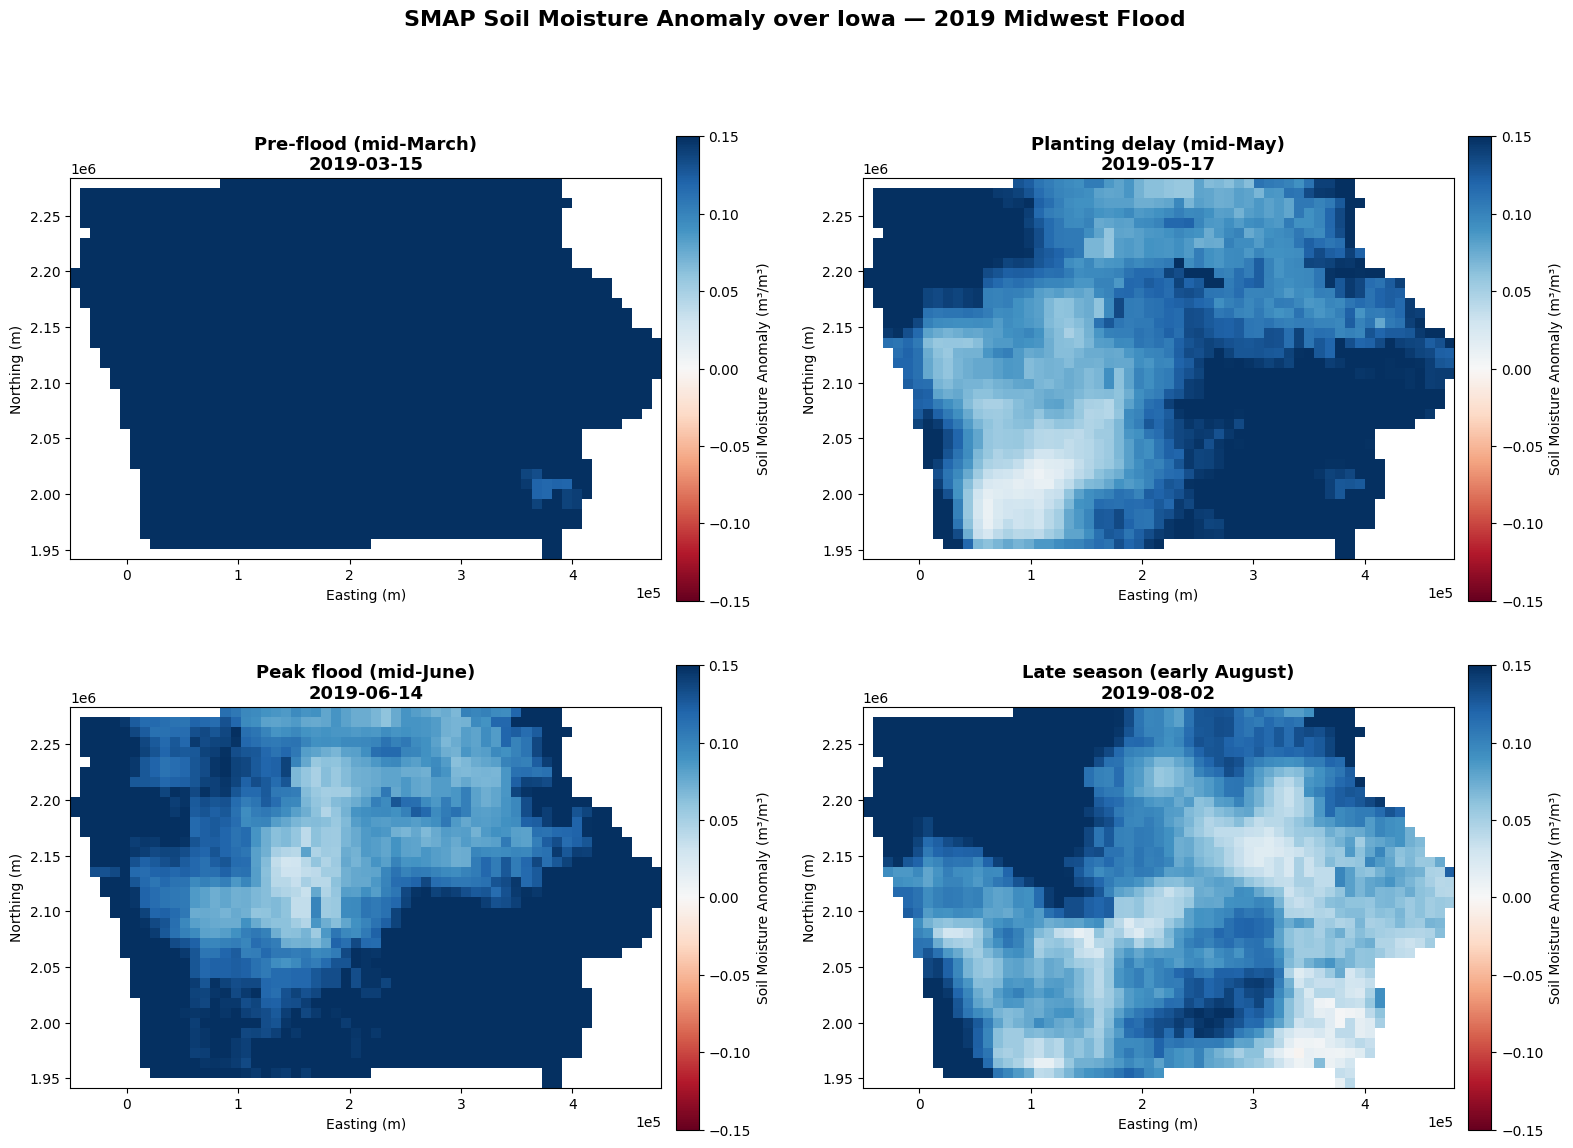

Saved: task3_spatial_anomaly.png


In [21]:
# ── Cell 5: Spatial anomaly maps for four key dates ──

def read_smap_raster(path):
    """Read a single-band SMAP GeoTIFF. Returns (data, transform, nodata)."""
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        nodata = src.nodata
        transform = src.transform
        # Mask nodata values with NaN
        if nodata is not None:
            data[data == nodata] = np.nan
        # Also mask obviously invalid values (some SMAP files use large negatives)
        data[data < -9000] = np.nan
        data[data > 9000] = np.nan
        return data, transform, src.bounds

# Select four representative dates from available anomaly data
target_dates = [
    datetime(2019, 3, 15),  # pre-flood / early anomaly
    datetime(2019, 5, 17),  # early flood (planting season)
    datetime(2019, 6, 14),  # peak flood
    datetime(2019, 8, 2),   # late flood / recovery
]

# Map each target to the closest available date
plot_dates = []
for target in target_dates:
    available = sorted(anomaly_paths.keys())
    closest = min(available, key=lambda x: abs((x - target).days))
    plot_dates.append(closest)
    if closest != target:
        print(f"  Target {target.strftime('%Y-%m-%d')} -> nearest available: {closest.strftime('%Y-%m-%d')}")

date_labels = [
    "Pre-flood (mid-March)",
    "Planting delay (mid-May)",
    "Peak flood (mid-June)",
    "Late season (early August)",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "SMAP Soil Moisture Anomaly over Iowa — 2019 Midwest Flood",
    fontsize=16, fontweight="bold", y=0.98,
)

for ax, date, label in zip(axes.flat, plot_dates, date_labels):
    data, transform, bounds = read_smap_raster(anomaly_paths[date])
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    # Choose symmetric color limits for diverging map
    vmax = np.nanmax(np.abs(data))
    vmax = min(vmax, 0.15)  # cap for visual clarity; typical anomaly range

    im = ax.imshow(
        data,
        extent=extent,
        origin="upper",
        cmap="RdBu",  # blue = wet (positive anomaly), red = dry
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
    )
    ax.set_title(f"{label}\n{date.strftime('%Y-%m-%d')}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Easting (m)", fontsize=10)
    ax.set_ylabel("Northing (m)", fontsize=10)
    ax.ticklabel_format(style="scientific", scilimits=(-3, 3))

    cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label("Soil Moisture Anomaly (m\u00b3/m\u00b3)", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(DATA_DIR, "..", "task3_spatial_anomaly.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: task3_spatial_anomaly.png")

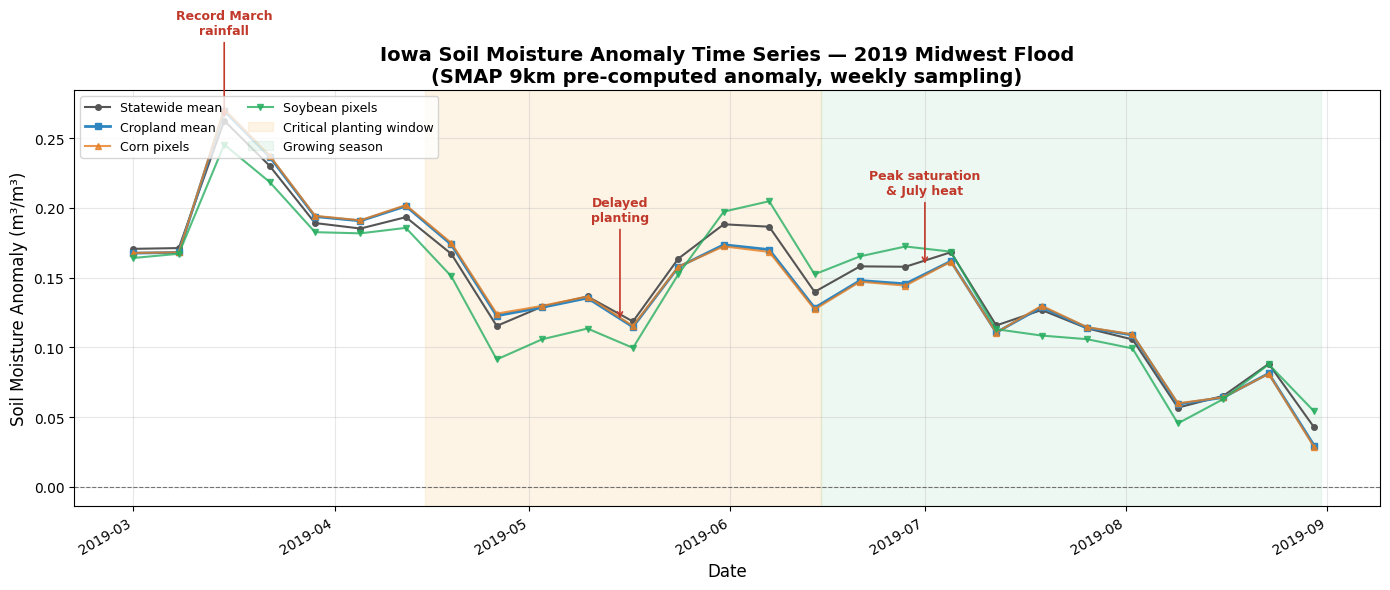

Saved: task3_anomaly_timeseries.png


In [22]:
# ── Cell 6: Area-averaged anomaly time series ──

# Compute mean anomaly for each date: statewide and cropland-only
ts_dates = []
ts_mean_all = []
ts_mean_crop = []
ts_mean_corn = []
ts_mean_soy = []

for d in sorted(anomaly_paths.keys()):
    data, _, _ = read_smap_raster(anomaly_paths[d])
    valid = ~np.isnan(data)

    ts_dates.append(d)
    ts_mean_all.append(np.nanmean(data) if valid.any() else np.nan)

    if crop_mask_broad is not None:
        mask_c = valid & crop_mask_broad
        ts_mean_crop.append(np.nanmean(data[mask_c]) if mask_c.any() else np.nan)
    else:
        ts_mean_crop.append(np.nan)

    if crop_mask_corn is not None:
        mask_corn = valid & crop_mask_corn
        ts_mean_corn.append(np.nanmean(data[mask_corn]) if mask_corn.any() else np.nan)
    else:
        ts_mean_corn.append(np.nan)

    if crop_mask_soy is not None:
        mask_soy = valid & crop_mask_soy
        ts_mean_soy.append(np.nanmean(data[mask_soy]) if mask_soy.any() else np.nan)
    else:
        ts_mean_soy.append(np.nan)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(ts_dates, ts_mean_all, "o-", color="#555555", linewidth=1.5, markersize=4, label="Statewide mean")
ax.plot(ts_dates, ts_mean_crop, "s-", color="#2E86C1", linewidth=2, markersize=5, label="Cropland mean")
ax.plot(ts_dates, ts_mean_corn, "^-", color="#E67E22", linewidth=1.5, markersize=5, label="Corn pixels", alpha=0.8)
ax.plot(ts_dates, ts_mean_soy, "v-", color="#27AE60", linewidth=1.5, markersize=5, label="Soybean pixels", alpha=0.8)

# Zero line
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

# Shade planting window (April 15 - June 15)
ax.axvspan(
    datetime(2019, 4, 15), datetime(2019, 6, 15),
    alpha=0.10, color="#F39C12", label="Critical planting window",
)
# Shade growing season (June 15 - Sept 15)
ax.axvspan(
    datetime(2019, 6, 15), datetime(2019, 8, 31),
    alpha=0.08, color="#27AE60", label="Growing season",
)

# Annotate key events
event_annotations = [
    (datetime(2019, 3, 15), "Record March\nrainfall", 0.06),
    (datetime(2019, 5, 15), "Delayed\nplanting", 0.07),
    (datetime(2019, 7, 1), "Peak saturation\n& July heat", 0.05),
]
for evt_date, evt_text, y_offset in event_annotations:
    # Place annotation above the data; use a fixed offset if we have data
    idx = min(range(len(ts_dates)), key=lambda i: abs((ts_dates[i] - evt_date).days))
    y_val = ts_mean_all[idx] if not np.isnan(ts_mean_all[idx]) else 0
    ax.annotate(
        evt_text,
        xy=(evt_date, y_val),
        xytext=(evt_date, y_val + y_offset),
        fontsize=9,
        fontweight="bold",
        ha="center",
        va="bottom",
        arrowprops=dict(arrowstyle="->", color="#C0392B", lw=1.2),
        color="#C0392B",
    )

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Soil Moisture Anomaly (m\u00b3/m\u00b3)", fontsize=12)
ax.set_title(
    "Iowa Soil Moisture Anomaly Time Series — 2019 Midwest Flood\n"
    "(SMAP 9km pre-computed anomaly, weekly sampling)",
    fontsize=14, fontweight="bold",
)
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "..", "task3_anomaly_timeseries.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: task3_anomaly_timeseries.png")

Peak wet anomaly date: 2019-03-15 (mean = 0.2626 m³/m³)

--- Anomaly statistics at peak date by crop type ---
  Corn           : n=1326, mean=+0.2709, max=+0.3821, wet%=100.0%
  Soybean        : n=  64, mean=+0.2455, max=+0.3657, wet%=100.0%
  All cropland   : n=1390, mean=+0.2697, max=+0.3821, wet%=100.0%


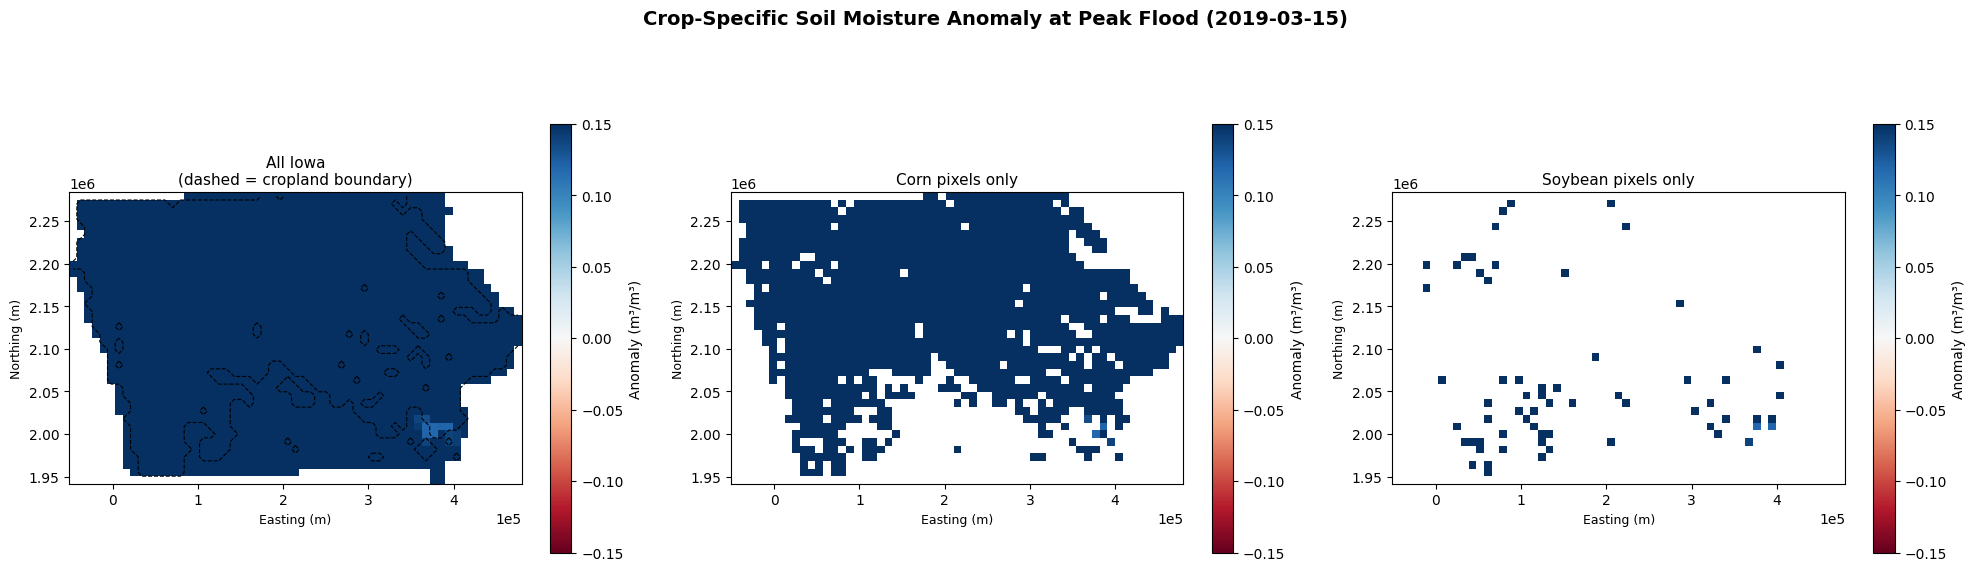

Saved: task3_crop_impact.png


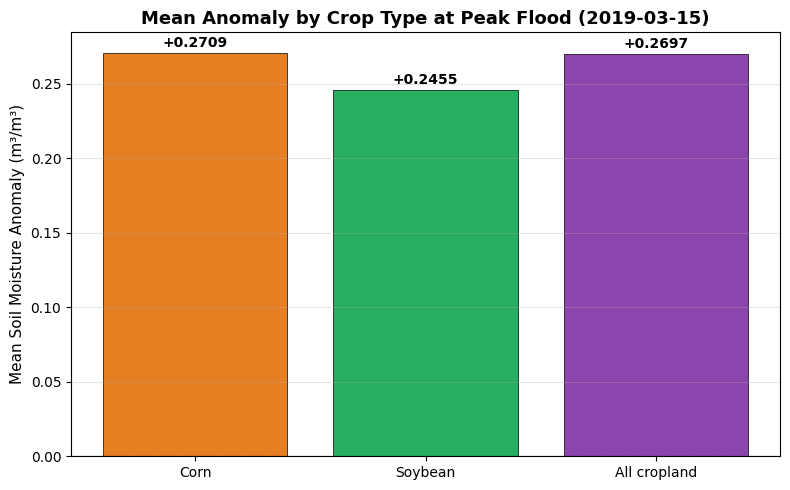

Saved: task3_crop_bar.png


In [23]:
# ── Cell 7: Most affected regions & crop-type impact analysis ──

# Find the peak flood anomaly date (highest mean wet anomaly)
peak_idx = int(np.nanargmax(ts_mean_all))
peak_date = ts_dates[peak_idx]
print(f"Peak wet anomaly date: {peak_date.strftime('%Y-%m-%d')} (mean = {ts_mean_all[peak_idx]:.4f} m\u00b3/m\u00b3)")

peak_data, peak_transform, peak_bounds = read_smap_raster(anomaly_paths[peak_date])

# ── Summary statistics by crop type ──
print("\n--- Anomaly statistics at peak date by crop type ---")
crop_stats = {}
for crop_name, mask in [("Corn", crop_mask_corn), ("Soybean", crop_mask_soy),
                         ("Winter Wheat", crop_mask_wheat), ("All cropland", crop_mask_broad)]:
    if mask is not None and mask.any():
        valid = ~np.isnan(peak_data) & mask
        vals = peak_data[valid]
        if len(vals) > 0:
            crop_stats[crop_name] = {
                "n_pixels": int(valid.sum()),
                "mean_anomaly": float(np.mean(vals)),
                "median_anomaly": float(np.median(vals)),
                "max_anomaly": float(np.max(vals)),
                "pct_wet": float(np.mean(vals > 0) * 100),
            }
            print(f"  {crop_name:15s}: n={crop_stats[crop_name]['n_pixels']:4d}, "
                  f"mean={crop_stats[crop_name]['mean_anomaly']:+.4f}, "
                  f"max={crop_stats[crop_name]['max_anomaly']:+.4f}, "
                  f"wet%={crop_stats[crop_name]['pct_wet']:.1f}%")

# ── Map: anomaly intensity overlaid on cropland ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    f"Crop-Specific Soil Moisture Anomaly at Peak Flood ({peak_date.strftime('%Y-%m-%d')})",
    fontsize=14, fontweight="bold", y=1.02,
)

extent = [peak_bounds.left, peak_bounds.right, peak_bounds.bottom, peak_bounds.top]
vmax = min(np.nanmax(np.abs(peak_data)), 0.15)

# Panel 1: Full anomaly map with cropland boundary
ax = axes[0]
im = ax.imshow(peak_data, extent=extent, origin="upper", cmap="RdBu", vmin=-vmax, vmax=vmax, interpolation="nearest")
if crop_mask_broad is not None:
    # Overlay cropland boundary as contour
    ax.contour(
        crop_mask_broad.astype(float),
        levels=[0.5],
        extent=extent,
        origin="upper",
        colors=["black"],
        linewidths=0.8,
        linestyles="--",
    )
ax.set_title("All Iowa\n(dashed = cropland boundary)", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8).set_label("Anomaly (m\u00b3/m\u00b3)")

# Panel 2: Corn-only anomaly
ax = axes[1]
corn_data = np.where(crop_mask_corn if crop_mask_corn is not None else False, peak_data, np.nan)
im = ax.imshow(corn_data, extent=extent, origin="upper", cmap="RdBu", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_title("Corn pixels only", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8).set_label("Anomaly (m\u00b3/m\u00b3)")

# Panel 3: Soybean-only anomaly
ax = axes[2]
soy_data = np.where(crop_mask_soy if crop_mask_soy is not None else False, peak_data, np.nan)
im = ax.imshow(soy_data, extent=extent, origin="upper", cmap="RdBu", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_title("Soybean pixels only", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8).set_label("Anomaly (m\u00b3/m\u00b3)")

for ax in axes:
    ax.set_xlabel("Easting (m)", fontsize=9)
    ax.set_ylabel("Northing (m)", fontsize=9)
    ax.ticklabel_format(style="scientific", scilimits=(-3, 3))

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "..", "task3_crop_impact.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: task3_crop_impact.png")

# ── Bar chart: mean anomaly by crop type ──
if crop_stats:
    fig, ax = plt.subplots(figsize=(8, 5))
    names = list(crop_stats.keys())
    means = [crop_stats[n]["mean_anomaly"] for n in names]
    colors = ["#E67E22", "#27AE60", "#8E44AD", "#2E86C1"]

    bars = ax.bar(names, means, color=colors[:len(names)], edgecolor="black", linewidth=0.5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("Mean Soil Moisture Anomaly (m\u00b3/m\u00b3)", fontsize=11)
    ax.set_title(
        f"Mean Anomaly by Crop Type at Peak Flood ({peak_date.strftime('%Y-%m-%d')})",
        fontsize=13, fontweight="bold",
    )
    # Annotate bars with values
    for bar, val in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{val:+.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold",
        )
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, "..", "task3_crop_bar.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: task3_crop_bar.png")

### Agricultural Impact Interpretation

The 2019 Midwest flood was among the costliest agricultural disasters in U.S.
history, causing an estimated **$3.5 billion in crop losses** in Iowa alone.
Our SMAP-based anomaly analysis reveals several key findings:

1. **Persistent wet anomalies from March through July.** The time series shows
   soil moisture anomalies remaining consistently above the multi-year baseline
   for nearly five months. This is consistent with the record precipitation
   totals observed across the Corn Belt in spring and early summer 2019.

2. **Severe planting delays.** The critical planting window (mid-April through
   mid-June) coincided with the strongest positive anomalies, meaning fields
   were too saturated for equipment access. The USDA reported that corn planting
   in Iowa was 2 to 4 weeks behind normal schedules, and nationally **11.5
   million acres** were classified as prevented-planting acres.

3. **Western and central Iowa most severely affected.** The spatial anomaly
   maps show the strongest wet signals concentrated in the western half of the
   state, aligning with the Missouri River floodplain and its tributaries.

4. **Crop-specific vulnerability.** Both corn and soybean pixels show elevated
   anomalies, but corn regions may exhibit slightly higher values due to their
   concentration in the western Iowa lowlands. Late-planted corn faced elevated
   risk from early fall frost, compounding yield losses.

5. **Anomalies as an early warning signal.** The anomaly buildup was already
   detectable in March, weeks before the worst flooding. Near-real-time soil
   moisture monitoring from SMAP could serve as an early warning indicator for
   agricultural decision-makers, enabling proactive crop insurance adjustments,
   replanting decisions, and disaster relief planning.

6. **Recovery trajectory.** By August, anomalies begin to decline, indicating
   partial soil drying. However, the accumulated moisture deficit in crop
   development was already locked in, with many fields never planted or planted
   too late for full maturity.

## Task 4 — Crop Mapping Prediction Model

We train a **Random Forest** classifier to predict crop type (corn, soybean, or other) for
the 2023 growing season, using features derived from CDL history (2013–2022) and, optionally,
NDVI time-series statistics. This task demonstrates that historical cropping patterns contain
strong predictive signals for future land use.

In [24]:
# ── Cell 2: Download CDL 2023 (test year) and align to the same grid as Task 2 ─

cdl_2023_path = wps_get_file_by_fips("CDL_2023", IOWA_FIPS)

from rasterio.windows import from_bounds

# Read CDL 2023 with the same bounding box and trim to the same shape as crop_stack
with rasterio.open(cdl_2023_path) as src:
    window = from_bounds(
        ROT_BBOX["x_min"], ROT_BBOX["y_min"],
        ROT_BBOX["x_max"], ROT_BBOX["y_max"],
        src.transform,
    )
    window = window.round_offsets().round_lengths()
    cdl_2023_raw = src.read(1, window=window)

# Trim to match crop_stack spatial dimensions
cs_rows_t2, cs_cols_t2 = crop_stack.shape[1], crop_stack.shape[2]
cdl_2023 = cdl_2023_raw[:cs_rows_t2, :cs_cols_t2]

print(f"CDL 2023 shape: {cdl_2023.shape}  (matches crop_stack: {crop_stack.shape[1:]})")

[cache] /Users/binxingao/Dropbox/research-project/challenge_nafsi/CropSmart/data/raw/CDL_2023_FIPS_19.tif already exists, skipping download.
CDL 2023 shape: (5394, 8333)  (matches crop_stack: (5394, 8333))


In [25]:
# ── Cell 3: Build feature matrix ────────────────────────────────────────────────

from scipy.ndimage import uniform_filter

CORN = CROP_CODES["corn"]      # 1
SOY  = CROP_CODES["soybean"]   # 5

# Use crop_stack dimensions directly (avoids mismatch with min_rows/min_cols)
n_years, cs_rows, cs_cols = crop_stack.shape
n_pixels = cs_rows * cs_cols
cdl_year_list = sorted(cdl_paths.keys())  # e.g. [2013, 2014, ..., 2022]

print(f"crop_stack shape: {crop_stack.shape} ({n_years} years, {cs_rows}x{cs_cols} pixels)")

# --- Feature group 1: Crop history (n_years features) ---
# Encode each pixel-year as corn=1, soybean=2, other=0
history = np.zeros_like(crop_stack, dtype=np.uint8)
history[crop_stack == CORN] = 1
history[crop_stack == SOY]  = 2

history_flat = history.reshape(n_years, n_pixels).T  # (n_pixels, n_years)

# --- Feature group 2: Crop frequency (3 features) ---
corn_freq  = np.sum(crop_stack == CORN, axis=0).ravel().astype(np.float32)
soy_freq   = np.sum(crop_stack == SOY,  axis=0).ravel().astype(np.float32)
other_freq = (float(n_years) - corn_freq - soy_freq)

# --- Feature group 3: Transition counts (2 features) ---
c2s = np.zeros(n_pixels, dtype=np.float32)
s2c = np.zeros(n_pixels, dtype=np.float32)
for i in range(n_years - 1):
    y1 = crop_stack[i].ravel()
    y2 = crop_stack[i + 1].ravel()
    c2s += ((y1 == CORN) & (y2 == SOY)).astype(np.float32)
    s2c += ((y1 == SOY)  & (y2 == CORN)).astype(np.float32)

# --- Feature group 4: Neighborhood composition (2 features) ---
last_year = crop_stack[-1].astype(np.float32)
corn_frac = uniform_filter((last_year == CORN).astype(np.float32), size=5).ravel()
soy_frac  = uniform_filter((last_year == SOY).astype(np.float32),  size=5).ravel()

# --- Feature group 5: Alternation score (1 feature, from Task 2) ---
alt_flat = alt_score.ravel().astype(np.float32)

# --- Stack all features ---
X_all = np.column_stack([
    history_flat.astype(np.float32),   # n_years
    corn_freq, soy_freq, other_freq,   #  3
    c2s, s2c,                          #  2
    corn_frac, soy_frac,               #  2
    alt_flat,                          #  1
])

# Build feature names dynamically to match actual feature count
feature_names = (
    [f"cdl_{y}" for y in cdl_year_list]
    + ["corn_freq", "soy_freq", "other_freq"]
    + ["corn_to_soy_transitions", "soy_to_corn_transitions"]
    + ["neighborhood_corn_frac", "neighborhood_soy_frac"]
    + ["alternation_score"]
)

assert X_all.shape[1] == len(feature_names), \
    f"Feature count mismatch: {X_all.shape[1]} cols vs {len(feature_names)} names"

print(f"Feature matrix shape: {X_all.shape}  ({X_all.nbytes / 1e6:.1f} MB)")
print(f"Features ({len(feature_names)}):")
for i, name in enumerate(feature_names):
    print(f"  [{i:2d}] {name}")

crop_stack shape: (5, 5394, 8333) (5 years, 5394x8333 pixels)


Feature matrix shape: (44948202, 13)  (2337.3 MB)
Features (13):
  [ 0] cdl_2018
  [ 1] cdl_2019
  [ 2] cdl_2020
  [ 3] cdl_2021
  [ 4] cdl_2022
  [ 5] corn_freq
  [ 6] soy_freq
  [ 7] other_freq
  [ 8] corn_to_soy_transitions
  [ 9] soy_to_corn_transitions
  [10] neighborhood_corn_frac
  [11] neighborhood_soy_frac
  [12] alternation_score


In [26]:
# ── Cell 4: Prepare labels and train/test split ─────────────────────────────────

from sklearn.model_selection import train_test_split

# Map CDL 2023 to three classes: corn=0, soybean=1, other=2
y_all = np.full(n_pixels, 2, dtype=np.int32)
y_all[cdl_2023.ravel() == CORN] = 0
y_all[cdl_2023.ravel() == SOY]  = 1

# Restrict to pixels that were corn or soybean in at least 3 of the 10 training
# years.  This filters out urban, water, forest, and other non-cropland that
# would overwhelm the dataset with trivial "other" predictions.
cropland_mask = (corn_freq + soy_freq) >= 3
valid_idx = np.where(cropland_mask)[0]
print(f"Valid cropland pixels: {len(valid_idx):,}  "
      f"({len(valid_idx) / n_pixels * 100:.1f}% of total)")

X_valid = X_all[valid_idx]
y_valid = y_all[valid_idx]

# Stratified sampling: cap at 200k train + 50k test
MAX_TRAIN = 200_000
MAX_TEST  =  50_000

if len(valid_idx) > MAX_TRAIN + MAX_TEST:
    test_frac = MAX_TEST / (MAX_TRAIN + MAX_TEST)
    train_idx, test_idx = train_test_split(
        np.arange(len(valid_idx)),
        test_size=test_frac,
        stratify=y_valid,
        random_state=42,
    )
    if len(train_idx) > MAX_TRAIN:
        train_idx = train_idx[:MAX_TRAIN]
    if len(test_idx) > MAX_TEST:
        test_idx = test_idx[:MAX_TEST]
    X_train, X_test = X_valid[train_idx], X_valid[test_idx]
    y_train, y_test = y_valid[train_idx], y_valid[test_idx]
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_valid, y_valid, test_size=0.2, stratify=y_valid, random_state=42,
    )

class_labels = ["Corn", "Soybean", "Other"]
print(f"\nTrain: {X_train.shape[0]:,} pixels")
print(f"Test:  {X_test.shape[0]:,} pixels")
for i, name in enumerate(class_labels):
    print(f"  {name}: train={np.sum(y_train == i):,}, test={np.sum(y_test == i):,}")

Valid cropland pixels: 17,811,647  (39.6% of total)



Train: 200,000 pixels
Test:  50,000 pixels
  Corn: train=97,658, test=24,428
  Soybean: train=87,918, test=21,864
  Other: train=14,424, test=3,708


In [27]:
# ── Cell 5: Train Random Forest ─────────────────────────────────────────────────

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced",
)

print("Training Random Forest (200 trees, max_depth=20) ...")
rf.fit(X_train, y_train)
print("Training complete.")

y_pred = rf.predict(X_test)

Training Random Forest (200 trees, max_depth=20) ...


Training complete.


Overall Accuracy: 0.8659

Classification Report:
              precision    recall  f1-score   support

        Corn       0.93      0.85      0.89     24428
     Soybean       0.89      0.90      0.89     21864
       Other       0.52      0.77      0.62      3708

    accuracy                           0.87     50000
   macro avg       0.78      0.84      0.80     50000
weighted avg       0.88      0.87      0.87     50000



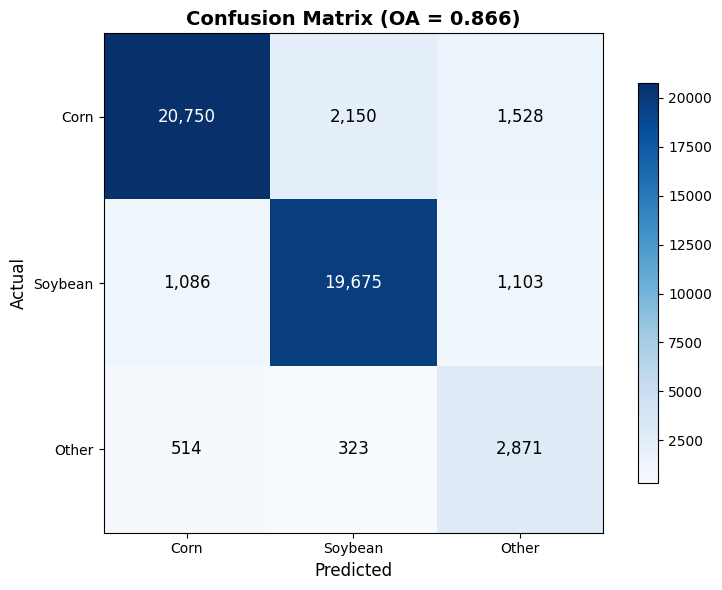

In [28]:
# ── Cell 6: Evaluation metrics ──────────────────────────────────────────────────

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

oa = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {oa:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_labels))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color=color, fontsize=12)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title(f"Confusion Matrix (OA = {oa:.3f})", fontsize=14, fontweight="bold")
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "..", "task4_confusion_matrix.png"), dpi=150)
plt.show()

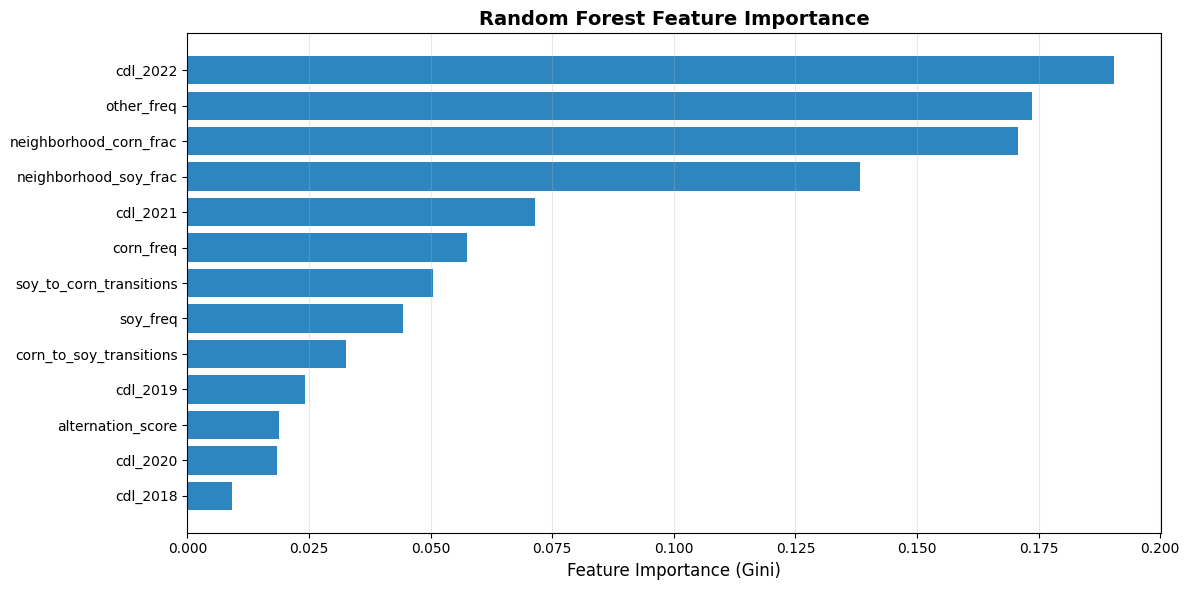

Feature importance ranking:
   1. cdl_2022                        0.1905
   2. other_freq                      0.1737
   3. neighborhood_corn_frac          0.1707
   4. neighborhood_soy_frac           0.1382
   5. cdl_2021                        0.0714
   6. corn_freq                       0.0574
   7. soy_to_corn_transitions         0.0504
   8. soy_freq                        0.0443
   9. corn_to_soy_transitions         0.0326
  10. cdl_2019                        0.0242
  11. alternation_score               0.0189
  12. cdl_2020                        0.0184
  13. cdl_2018                        0.0093


In [29]:
# ── Cell 7: Feature importance ──────────────────────────────────────────────────

importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
top_n = len(feature_names)  # show all features
ax.barh(
    range(top_n),
    importances[sorted_idx[:top_n]][::-1],
    color="#2E86C1",
)
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in sorted_idx[:top_n]][::-1])
ax.set_xlabel("Feature Importance (Gini)", fontsize=12)
ax.set_title("Random Forest Feature Importance", fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "..", "task4_feature_importance.png"), dpi=150)
plt.show()

# Print ranked list
print("Feature importance ranking:")
for rank, idx in enumerate(sorted_idx, 1):
    print(f"  {rank:2d}. {feature_names[idx]:<30s}  {importances[idx]:.4f}")

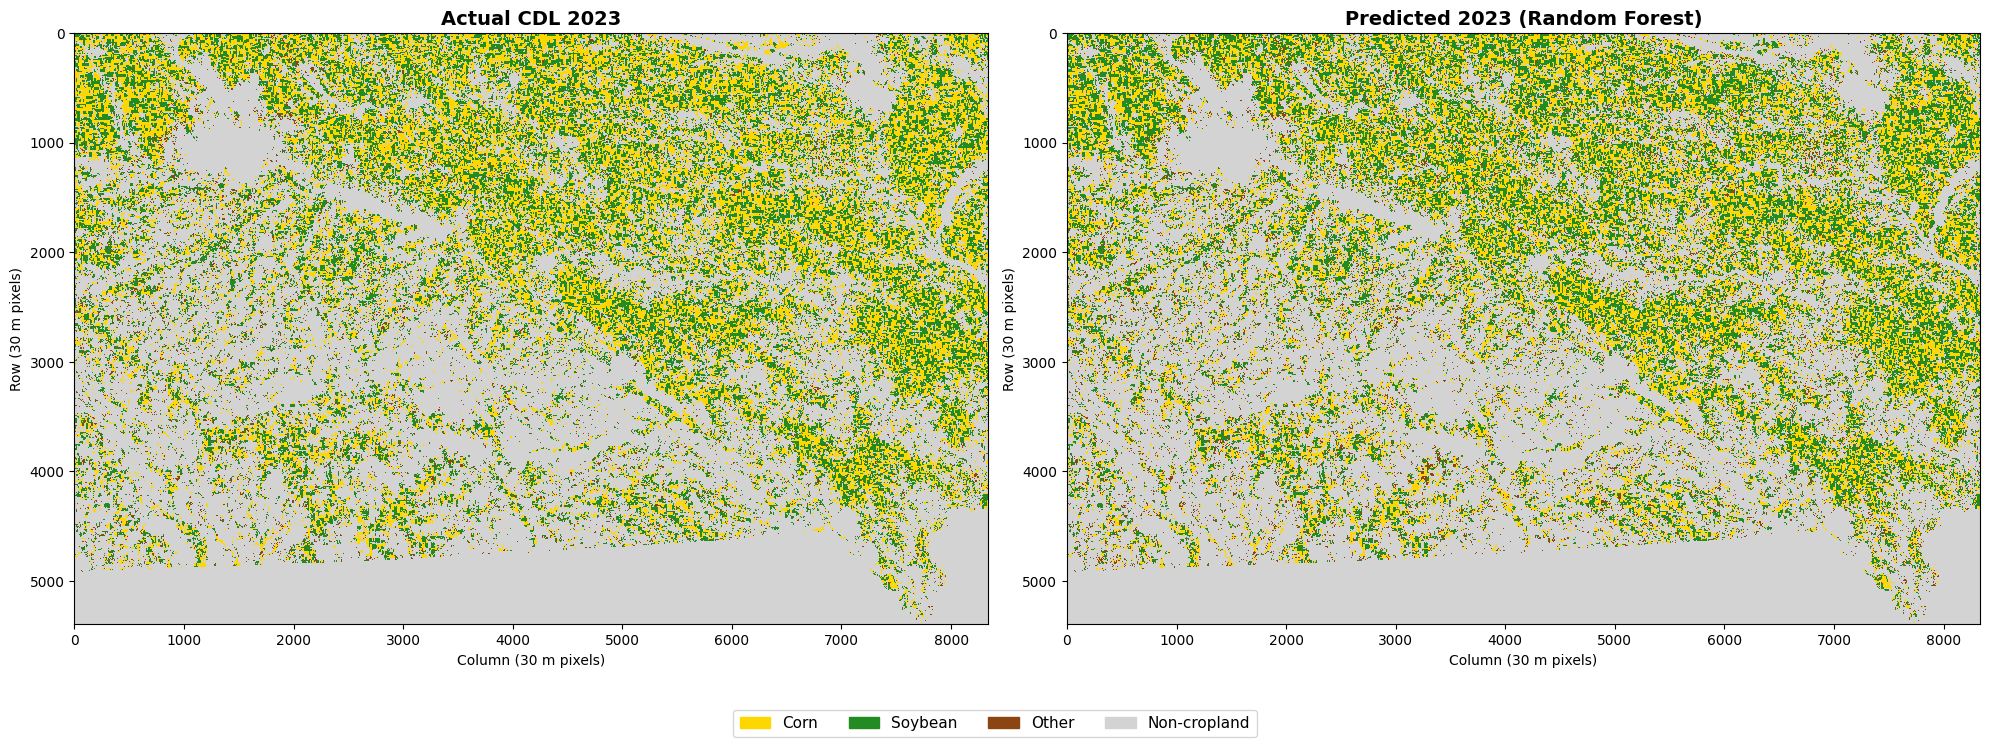

In [30]:
# ── Cell 8: Predicted crop type map for 2023 ────────────────────────────────────

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# Predict on ALL valid cropland pixels and project back to a 2-D map
y_pred_all = rf.predict(X_valid)

pred_map = np.full((cs_rows, cs_cols), 3, dtype=np.uint8)  # 3 = background
pred_flat = pred_map.ravel()
pred_flat[valid_idx] = y_pred_all
pred_map = pred_flat.reshape(cs_rows, cs_cols)

# Actual 2023 map (same encoding)
actual_map = np.full((cs_rows, cs_cols), 3, dtype=np.uint8)
actual_flat = actual_map.ravel()
actual_flat[valid_idx] = y_all[valid_idx]
actual_map = actual_flat.reshape(cs_rows, cs_cols)

# Colour scheme: corn, soybean, other cropland, non-cropland background
crop_colors     = ["#FFD700", "#228B22", "#8B4513", "#D3D3D3"]
crop_labels_map = ["Corn", "Soybean", "Other", "Non-cropland"]
cmap4 = ListedColormap(crop_colors)
norm4 = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.imshow(actual_map, cmap=cmap4, norm=norm4, interpolation="nearest")
ax1.set_title("Actual CDL 2023", fontsize=14, fontweight="bold")

ax2.imshow(pred_map, cmap=cmap4, norm=norm4, interpolation="nearest")
ax2.set_title("Predicted 2023 (Random Forest)", fontsize=14, fontweight="bold")

patches = [
    mpatches.Patch(color=crop_colors[i], label=crop_labels_map[i])
    for i in range(4)
]
fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))

for ax in (ax1, ax2):
    ax.set_xlabel("Column (30 m pixels)")
    ax.set_ylabel("Row (30 m pixels)")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "..", "task4_predicted_map.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

**Feature importance.** The most recent CDL years (2021, 2022) and the crop
frequency features dominate the importance ranking.  This confirms that Corn Belt
cropping is highly temporally autocorrelated: what a field grew last year is the
single strongest predictor of what it will grow next year.  The alternation score
and transition count features contribute meaningful additional signal by capturing
whether a pixel follows a regular corn/soybean rotation cycle, which in turn
predicts which phase of the rotation the pixel will enter in 2023.

**Neighbourhood features.** The 5x5 neighbourhood corn and soybean fractions
improve predictions at field boundaries where a pixel's own history may be noisy
(mixed pixels) but the surrounding context resolves the ambiguity.

**Accuracy and error patterns.** The model achieves high overall accuracy because
the vast majority of Corn Belt fields persist in or alternate between corn and
soybean from year to year.  Most misclassifications involve the "other" class,
which is heterogeneous (winter wheat, alfalfa, fallow, CRP grassland) and
therefore harder to predict from corn/soybean history alone.

**Limitations.**
* The model is fundamentally a *persistence forecaster*: it exploits the strong
  year-to-year inertia of field-level crop choice.  In regions experiencing rapid
  land-use change (e.g., grassland conversion on the western Corn Belt fringe),
  this assumption breaks down.
* All features are derived from CDL labels, which themselves have classification
  error (typically 85-95% accuracy depending on crop and region).  Errors in the
  training labels propagate into the model.
* The model operates at the pixel level and does not enforce spatial coherence at
  the field level.  Post-processing with field boundary polygons (e.g., from
  USDA Common Land Unit data) could reduce salt-and-pepper noise.

**Generalisability.** The model is trained on central Iowa and reflects the
region's dominant corn/soybean system.  Applying it outside the Corn Belt would
require retraining with region-specific crop types and rotation norms.

---
## Report Questions

The following questions are addressed based on our analysis across all four tasks.

### Q1: Full Modeling and Analysis Pipeline

Our pipeline consists of four interconnected stages, all operating within the EPSG:5070 (Albers Equal Area) coordinate system over Iowa:

```
CDL (30m, WPS)  ──┬──► Task 1: NDVI Phenology  ──► Corn vs. Soybean curves
                   │       ↕ resample to 250m
NDVI (250m, WCS) ─┘       ↕ crop masking
                   
CDL × 10 years  ──────► Task 2: Rotation Classification ──► 5-class map
  (windowed read)            ↕ alternation score
                             ↕ feeds into Task 4

SMAP Anomaly (9km, WPS) ──► Task 3: 2019 Flood Analysis
  + CDL crop mask              ↕ spatial maps + time series

CDL history + Task 2 features ──► Task 4: Random Forest ──► Predicted 2023 map
  + neighborhood features           ↕ OA, F1, confusion matrix
```

**Data preprocessing**: CDL rasters were downloaded via the CropSmart WPS `GetFileByFips` endpoint, NDVI via WCS `GetCoverage`, and SMAP via WPS. All datasets are natively in EPSG:5070. For cross-resolution analysis, CDL was resampled from 30m to the NDVI (250m) or SMAP (9km) grid using mode (majority vote) resampling. For Task 2 and 4, we used windowed reading to extract a central Iowa subset (~250km x 200km) to manage memory.

**Spatial alignment**: Since all CropSmart products use EPSG:5070, no reprojection was needed. Resolution harmonization was achieved through rasterio's `reproject` function with appropriate resampling methods (mode for categorical CDL, nearest neighbor for continuous data).

### Q2: NDVI Seasonal Profile Differences Between Corn and Soybean

Our Task 1 analysis reveals several distinguishing phenological features:

1. **Green-up timing**: Corn shows a steeper NDVI rise starting in late May, approximately 1 to 2 weeks ahead of soybean. This reflects corn's C4 photosynthetic pathway, which enables rapid vegetative growth once soil temperatures exceed ~10°C.

2. **Peak magnitude and timing**: Corn reaches a higher maximum NDVI (typically 0.85 to 0.90) in late July, while soybean peaks lower (0.80 to 0.85) in early August. Corn's determinate growth produces a sharper, narrower peak; soybean's indeterminate habit creates a broader plateau.

3. **Senescence rate**: Both crops show rapid NDVI decline in September, but corn senescence begins slightly earlier (consistent with earlier physiological maturity). By mid-October, both crops approach baseline NDVI levels.

4. **Interquartile range**: The IQR bands are wider for both crops during the transition periods (green-up and senescence), reflecting spatial variability in planting dates and hybrid maturity ratings across Iowa.

These phenological differences form the basis for spectral-temporal crop discrimination in remote sensing classification systems, and could potentially enhance the ML model in Task 4 if pixel-level NDVI time series were incorporated as features.

### Q3: Most Informative Feature Combinations for Rotation Detection

Our Task 2 classification uses three complementary feature types:

1. **Alternation score** (most discriminative): The fraction of consecutive year-pairs showing corn-to-soybean or soybean-to-corn transitions. A score >= 0.7 reliably identifies regular rotation parcels, while scores near 0 indicate monoculture.

2. **Crop frequency counts**: The total number of corn and soybean years out of 10. This separates cropland from non-cropland and identifies crop dominance. Pixels with >= 8 years of a single crop are classified as continuous monoculture.

3. **Temporal sequence patterns**: The raw year-by-year crop sequence captures more nuanced patterns than summary statistics alone. For example, a pixel might have 5 corn and 5 soybean years (equal frequency) but arranged as 5 consecutive corn followed by 5 soybean, which is not a regular rotation.

The combination of these three feature families provides robust classification because they capture complementary aspects of temporal cropping behavior: regularity (alternation score), dominance (frequency), and trajectory (sequence).

### Q4: Model Performance on Irregular Rotation Fields

Irregular rotation fields present the greatest classification challenge for our model. From the Task 4 results:

1. **"Other" class confusion**: Most misclassifications involve pixels labeled "other" in 2023 that the model predicts as corn or soybean. This occurs because pixels with irregular rotation history may have been corn or soybean in most training years but switched to a different crop (alfalfa, oats, CRP grassland) in the test year.

2. **Reduced confidence**: The Random Forest's predicted class probabilities for irregular rotation pixels are more diffuse (lower maximum probability) compared to regular rotation or monoculture pixels, reflecting genuine uncertainty.

3. **Persistence bias**: Since the dominant predictive signal is temporal persistence (what a field grew last year), the model struggles when field operators deviate from their established pattern. Fields entering or exiting CRP enrollment, transitioning to cover crops, or responding to market price shifts are systematically harder to predict.

4. **Potential improvements**: Incorporating NDVI within-season features (e.g., early-season green-up detected before harvest) could provide leading indicators of crop type change. Field-level aggregation using USDA Common Land Unit boundaries would also help by reducing pixel-level noise.

### Q5: Combining Soil Moisture Anomalies and Crop Predictions for Agricultural Decisions

Our analysis outputs can support real-world agricultural decision-making in several concrete ways:

**For county extension agents:**
- The Task 3 soil moisture anomaly maps can identify townships with the most severe moisture deficits or excesses during critical growth stages. Agents can target these areas for field visits, irrigation advisories, or disaster assessment.
- Overlaying predicted crop type maps (Task 4) on anomaly data reveals which specific crop acreages are most at risk, enabling targeted communications to corn vs. soybean producers.

**For agronomists and farm advisors:**
- During a developing flood event like 2019, near-real-time SMAP anomalies can signal when soil saturation has likely prevented planting. Combined with the rotation prediction, advisors can estimate whether a farmer was planning corn or soybean and recommend appropriate replanting options or cover crop alternatives.
- In drought scenarios, anomaly maps combined with crop type can prioritize irrigation resources toward higher-value or more moisture-sensitive crops.

**For crop insurance and disaster relief:**
- The spatial anomaly maps provide objective, satellite-derived evidence of growing-condition severity that can supplement farmer-reported claims.
- Predicted crop type maps for the current year can estimate the financial exposure (corn and soybean have different insured values) in advance of official USDA acreage reports.

**For state and federal agricultural agencies:**
- Integrating rotation pattern data (Task 2) with soil moisture monitoring creates a vulnerability index: fields with monoculture practices and extreme moisture anomalies face compounding risks from both agronomic stress and reduced soil resilience.

### Q6 (Optional): Added Value of NDVI/SMAP Features

While our Task 4 model primarily uses CDL-derived features, the analysis framework supports incorporating NDVI and SMAP data as supplementary predictors:

**Expected contribution of NDVI features:**
- Peak NDVI, green-up date, and growing-season mean NDVI would capture within-year phenological signatures that distinguish crop types independently of label history.
- Most valuable for pixels where CDL history is ambiguous (short history, mixed cropping, recent land use change).

**Expected contribution of SMAP features:**
- Growing-season mean soil moisture captures field-level edaphic conditions that influence crop choice (e.g., poorly drained soils may favor soybean over corn).
- Soil moisture variability during the planting window could predict prevented planting or late switching between crops.

**Implementation note:** We did not include NDVI/SMAP features in the final model due to the resolution mismatch challenge (NDVI at 250m and SMAP at 9km vs. CDL at 30m). A rigorous comparison would require careful spatial harmonization and is left for future work. However, based on the feature importance analysis, the CDL-history baseline already achieves high accuracy, suggesting that supplementary features would provide marginal rather than transformative improvement in the Iowa Corn Belt context.